In [1]:
import cdms
import numpy as np
import os, sys 
import ROOT
from cats.cdataframe import CDataFrame
from CDMSDataCatalog import CDMSDataCatalog
import supercuts
import glob
from uncertainties import ufloat
import math

import matplotlib.pyplot as plt
%matplotlib inline

CDMS = os.environ["CDMS"] # set in .bash_profile
stylesheet = os.path.join(CDMS,"scripts","stylesheets","blues.mplstyle")
plt.style.use(stylesheet)

sys.path.append(os.path.join(os.path.join(CDMS,"scripts")))
import setup
import detectorLayout

Welcome to JupyROOT 6.28/10


In [2]:
def str_with_err(value, error):
    digits = -int(math.floor(math.log10(error)))
    return "{0:.{2}f}({1:.0f})".format(value, error*10**digits, digits)

In [3]:
ProdTag = 'CUTE_T3_GeActivation_v2.1.1_V05-00_P0.2.'

In [4]:
filepath = np.sort(glob.glob(f'/scratch/group/mitchcomp/CDMS/data/CDMS/CUTE/R37/Processed/Tests/{ProdTag}/Submerged/{ProdTag}_232312??_??????.root'))

In [5]:
det = 1 # detector number

df = CDataFrame("rqDir/zip"+str(det), filepath, friends = [[x+":rqDir/eventTree" for x in filepath]])

In [6]:
## Apply some basic data quality filters and get the RQs you're interested in
logfile = '"cute_tower3testing.log"'
df = df.Define("LEDLogFile", logfile) 
df = df.CDefine("LEDOn", supercuts.ledOn_old, ["EventTime", "LEDLogFile"])
df = df.Filter("!LEDOn")
df_filtered = df.Filters(["TriggerType == 1", "TriggerDetectorNum=="+str(det), "PTOFamps>0"])

In [7]:
RQs = (["PTOFamps"] + ['P' + label + 'S' + sequence + 'OFamps' for sequence in ['1', '2'] for label in ['A', 'B', 'C', 'D', 'E', 'F']])
df_rqs = df_filtered.AsNumpy(RQs)

In [8]:
L_peak_bins = np.linspace(2.5, 5, 51)
K_peak_bins = np.linspace(22, 30, 41)

Text(0, 1, 'Count / (0.05 $\\mathrm{\\mu A}$)')

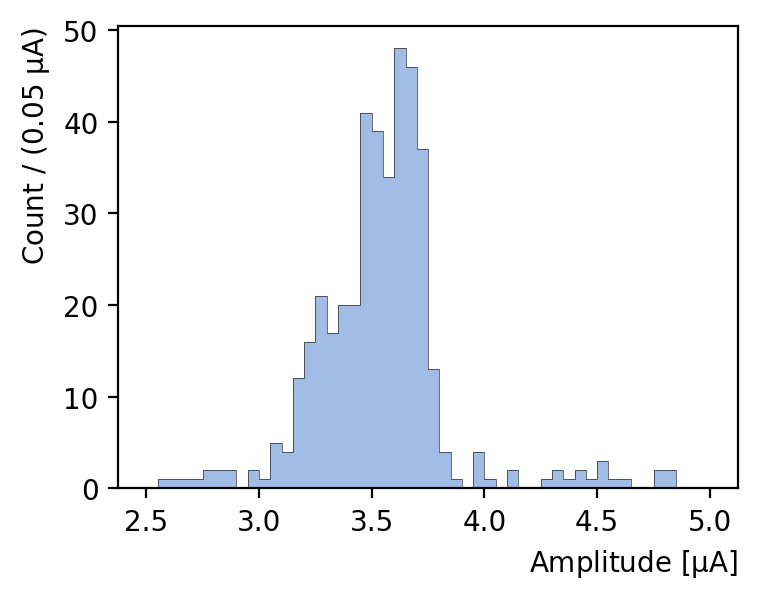

In [9]:
plt.figure(figsize=(4,3), dpi=200)
plt.hist(df_rqs['PTOFamps']*1e6, bins=L_peak_bins, alpha = 1)
plt.hist(df_rqs['PTOFamps']*1e6, bins=L_peak_bins, histtype='step', color = 'black', lw = 0.2)
plt.xlabel(r"Amplitude [$\mathrm{\mu A}$]")
plt.ylabel("Count / (0.05 $\mathrm{\mu A}$)")

Text(0, 1, 'Count / (0.2 $\\mathrm{\\mu A}$)')

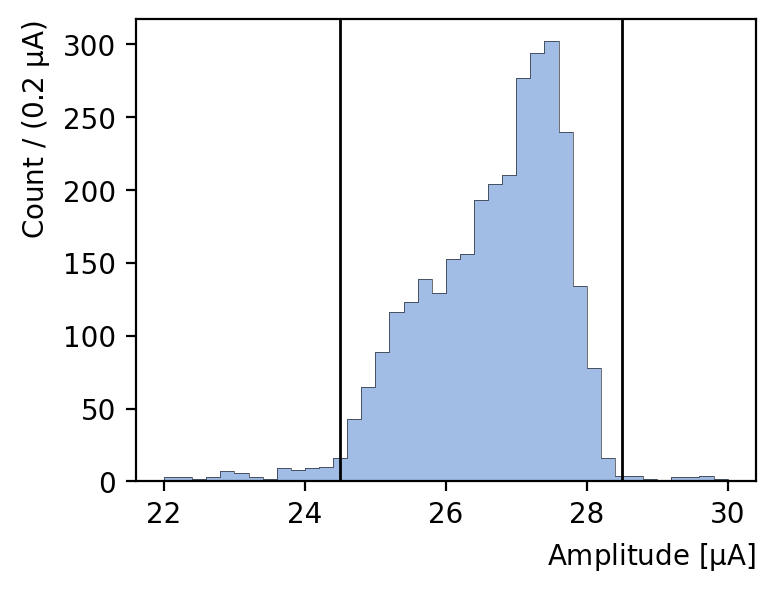

In [10]:
plt.figure(figsize=(4,3), dpi=200)
plt.hist(df_rqs['PTOFamps']*1e6, bins=K_peak_bins, alpha = 1)
plt.hist(df_rqs['PTOFamps']*1e6, bins=K_peak_bins, histtype='step', color = 'black', lw = 0.2)
plt.axvline(24.5, 0, 1, color = 'black', lw = 1)
plt.axvline(28.5, 0, 1, color = 'black', lw = 1)

plt.xlabel(r"Amplitude [$\mathrm{\mu A}$]")
plt.ylabel("Count / (0.2 $\mathrm{\mu A}$)")

In [13]:
c = ['#3D6CA5', '#92C0DC', '#F9965C', '#D72B22']

In [14]:
K_peak_cut = (df_rqs['PTOFamps'] >= 24.5e-6) & (df_rqs['PTOFamps'] <= 28.5e-6)

In [15]:
maxOF1 = np.array([np.max([df_rqs['P' + i + 'S1OFamps'][j] for i in ['A', 'B', 'C', 'D', 'E', 'F']]) for j in range(len(df_rqs['PTOFamps']))])
maxOF2 = np.array([np.max([df_rqs['P' + i + 'S2OFamps'][j] for i in ['A', 'B', 'C', 'D', 'E', 'F']]) for j in range(len(df_rqs['PTOFamps']))])
psum = np.sum([df_rqs[i] for i in ['P' + i + 'S' + j + 'OFamps' for j in ['1', '2'] for i in ['A', 'B', 'C', 'D', 'E', 'F']]], axis = 0)

In [16]:
Fsum = np.sum([df_rqs[i] for i in ['PFS' + sequence + 'OFamps' for sequence in ['1', '2']]], axis = 0)
Bsum = np.sum([df_rqs[i] for i in ['PBS' + sequence + 'OFamps' for sequence in ['1', '2']]], axis = 0)
Asum = np.sum([df_rqs[i] for i in ['PAS' + sequence + 'OFamps' for sequence in ['1', '2']]], axis = 0)
Wedgesum = np.sum([df_rqs[i] for i in ['P' + label + 'S' + sequence + 'OFamps' for sequence in ['1', '2'] for label in ['C', 'D', 'E']]], axis = 0)

In [17]:
F1cut = df_rqs['PFS1OFamps'] == maxOF1
F2cut = df_rqs['PFS2OFamps'] == maxOF2
Fcut = F1cut & F2cut

(-0.15, 0.735)

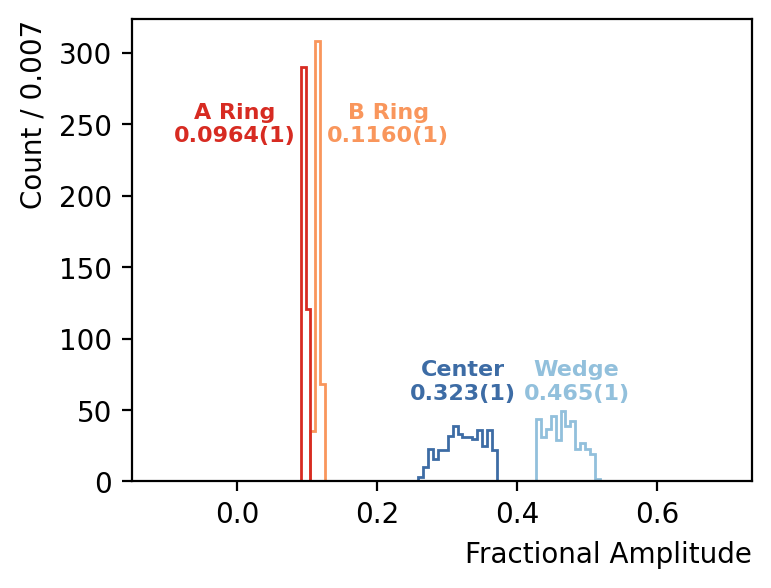

In [44]:
plt.figure(figsize=(4,3), dpi=200)
bins = np.linspace(0, 0.7, 101)

plt.hist((Fsum/psum)[K_peak_cut & Fcut], bins, histtype='step', color = c[0], lw = 1)
Fmean = np.mean((Fsum/psum)[K_peak_cut & Fcut])
Fmeanerr = np.std((Fsum/psum)[K_peak_cut & Fcut]) / np.sqrt(sum(K_peak_cut & Fcut))
plt.text(Fmean, 70, 'Center\n' + str_with_err(Fmean, Fmeanerr), color = c[0], va = 'center', ha = 'center', fontweight = 'bold', fontsize = 8)

plt.hist((Wedgesum/psum)[K_peak_cut & Fcut], bins, histtype='step', color = c[1], lw = 1)
Wedgemean = np.mean((Wedgesum/psum)[K_peak_cut & Fcut])
Wedgemeanerr = np.std((Wedgesum/psum)[K_peak_cut & Fcut]) / np.sqrt(sum(K_peak_cut & Fcut))
plt.text(Wedgemean + 0.02, 70, 'Wedge\n' + str_with_err(Wedgemean, Wedgemeanerr), color = c[1], va = 'center', ha = 'center', fontweight = 'bold', fontsize = 8)

plt.hist((Bsum/psum)[K_peak_cut & Fcut], bins, histtype='step', color = c[2], lw = 1)
Bmean = np.mean((Bsum/psum)[K_peak_cut & Fcut])
Bmeanerr = np.std((Bsum/psum)[K_peak_cut & Fcut]) / np.sqrt(sum(K_peak_cut & Fcut))
plt.text(Bmean + 0.1, 250, 'B Ring\n' + str_with_err(Bmean, Bmeanerr), color = c[2], va = 'center', ha = 'center', fontweight = 'bold', fontsize = 8)

plt.hist((Asum/psum)[K_peak_cut & Fcut], bins, histtype='step', color = c[3], lw = 1)
Amean = np.mean((Asum/psum)[K_peak_cut & Fcut])
Ameanerr = np.std((Asum/psum)[K_peak_cut & Fcut]) / np.sqrt(sum(K_peak_cut & Fcut))
plt.text(Amean - 0.1, 250, 'A Ring\n' + str_with_err(Amean, Ameanerr), color = c[3], va = 'center', ha = 'center', fontweight = 'bold', fontsize = 8)

plt.xlabel(r"Fractional Amplitude")
plt.ylabel("Count / 0.007")
plt.xlim(-0.15, None)

In [67]:
C1cut = df_rqs['PCS1OFamps'] == maxOF1
D1cut = df_rqs['PDS1OFamps'] == maxOF1
E1cut = df_rqs['PES1OFamps'] == maxOF1

C2cut = df_rqs['PCS2OFamps'] == maxOF2
D2cut = df_rqs['PDS2OFamps'] == maxOF2
E2cut = df_rqs['PES2OFamps'] == maxOF2

Wedge1cut = (C1cut | D1cut | E1cut)
Wedge2cut = (C2cut | D2cut | E2cut)

Wedgecut = Wedge1cut & Wedge2cut

Text(0, 1, 'Count / 0.007')

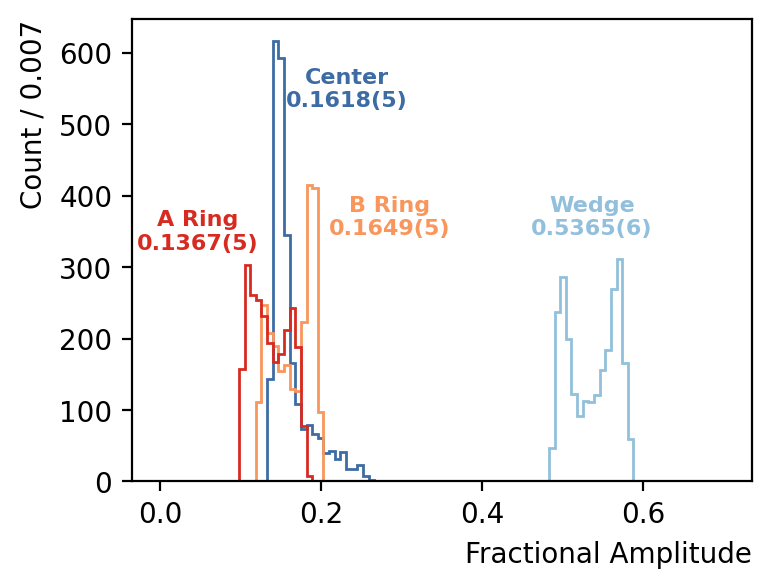

In [68]:
plt.figure(figsize=(4,3), dpi=200)
bins = np.linspace(0, 0.7, 101)
plt.hist((Fsum/psum)[K_peak_cut & Wedgecut], bins, histtype='step', color = c[0], lw = 1)
Fmean = np.mean((Fsum/psum)[K_peak_cut & Wedgecut])
Fmeanerr = np.std((Fsum/psum)[K_peak_cut & Wedgecut]) / np.sqrt(sum(K_peak_cut & Wedgecut))
plt.text(Fmean + 0.07, 550, 'Center\n' + str_with_err(Fmean, Fmeanerr), color = c[0], va = 'center', ha = 'center', fontweight = 'bold', fontsize = 8)

plt.hist((Wedgesum/psum)[K_peak_cut & Wedgecut], bins, histtype='step', color = c[1], lw = 1)
Wedgemean = np.mean((Wedgesum/psum)[K_peak_cut & Wedgecut])
Wedgemeanerr = np.std((Wedgesum/psum)[K_peak_cut & Wedgecut]) / np.sqrt(sum(K_peak_cut & Wedgecut))
plt.text(Wedgemean, 370, 'Wedge\n' + str_with_err(Wedgemean, Wedgemeanerr), color = c[1], va = 'center', ha = 'center', fontweight = 'bold', fontsize = 8)

plt.hist((Bsum/psum)[K_peak_cut & Wedgecut], bins, histtype='step', color = c[2], lw = 1)
Bmean = np.mean((Bsum/psum)[K_peak_cut & Wedgecut])
Bmeanerr = np.std((Bsum/psum)[K_peak_cut & Wedgecut]) / np.sqrt(sum(K_peak_cut & Wedgecut))
plt.text(Bmean + 0.12, 370, 'B Ring\n' + str_with_err(Bmean, Bmeanerr), color = c[2], va = 'center', ha = 'center', fontweight = 'bold', fontsize = 8)

plt.hist((Asum/psum)[K_peak_cut & Wedgecut], bins, histtype='step', color = c[3], lw = 1)
Amean = np.mean((Asum/psum)[K_peak_cut & Wedgecut])
Ameanerr = np.std((Asum/psum)[K_peak_cut & Wedgecut]) / np.sqrt(sum(K_peak_cut & Wedgecut))
plt.text(Amean - 0.09, 350, 'A Ring\n' + str_with_err(Amean, Ameanerr), color = c[3], va = 'center', ha = 'center', fontweight = 'bold', fontsize = 8)

plt.xlabel(r"Fractional Amplitude")
plt.ylabel("Count / 0.007")
#plt.xlim(-0.15, None)

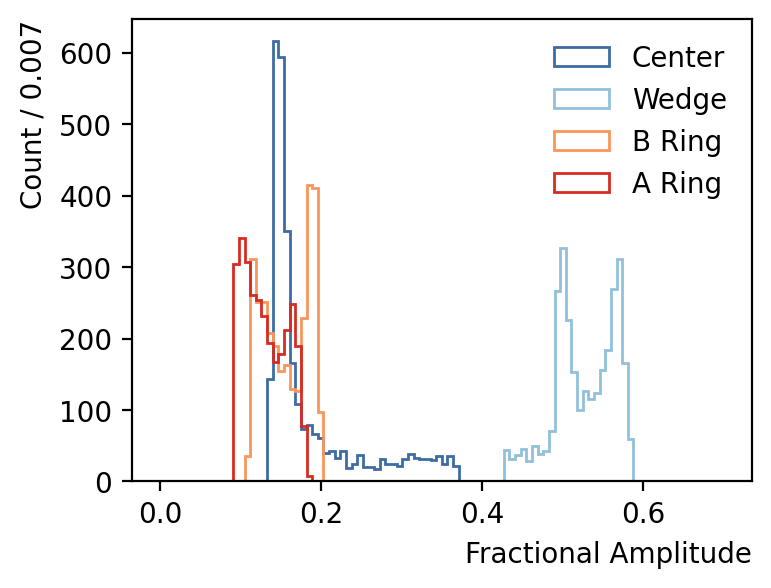

In [78]:
plt.figure(figsize=(4,3), dpi=200)
bins = np.linspace(0, 0.7, 101)
plt.hist((Fsum/psum)[K_peak_cut], bins, histtype='step', color = c[0], lw = 1, label = 'Center')

plt.hist((Wedgesum/psum)[K_peak_cut], bins, histtype='step', color = c[1], lw = 1, label = 'Wedge')

plt.hist((Bsum/psum)[K_peak_cut], bins, histtype='step', color = c[2], lw = 1, label = 'B Ring')

plt.hist((Asum/psum)[K_peak_cut], bins, histtype='step', color = c[3], lw = 1, label = 'A Ring')

plt.xlabel(r"Fractional Amplitude")
plt.ylabel("Count / 0.007")
plt.legend()

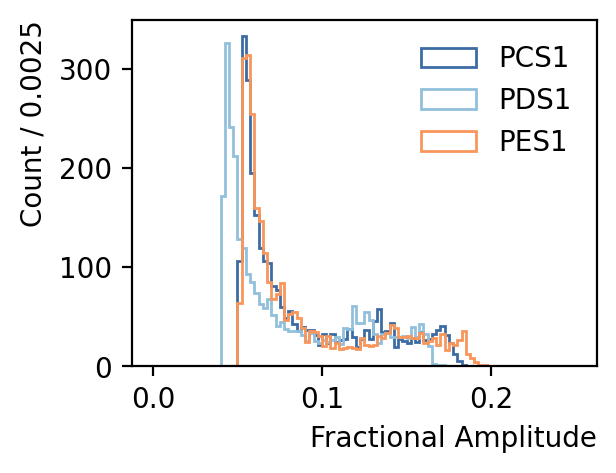

In [97]:
plt.figure(figsize=(4*0.75,3*0.75), dpi=200)
bins = np.linspace(0, 0.25, 101)

plt.hist(((df_rqs['PCS1OFamps'])/psum)[K_peak_cut], bins, histtype='step', color = c[0], lw = 1, label = 'PCS1')
plt.hist(((df_rqs['PDS1OFamps'])/psum)[K_peak_cut], bins, histtype='step', color = c[1], lw = 1, label = 'PDS1')
plt.hist(((df_rqs['PES1OFamps'])/psum)[K_peak_cut], bins, histtype='step', color = c[2], lw = 1, label = 'PES1')

plt.xlabel(r"Fractional Amplitude")
plt.ylabel("Count / 0.0025")
plt.legend()

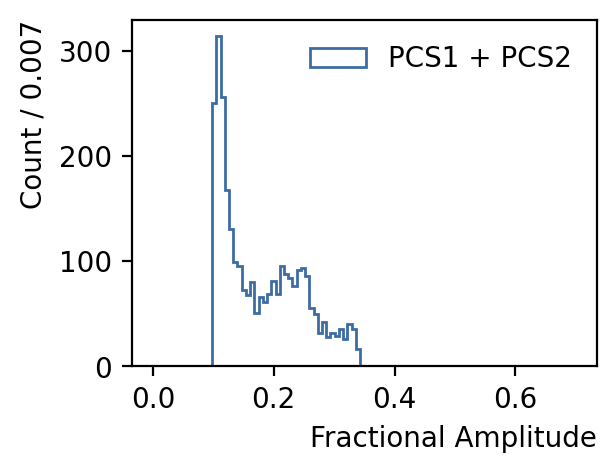

In [94]:
plt.figure(figsize=(4*0.75,3*0.75), dpi=200)
bins = np.linspace(0, 0.7, 101)

plt.hist(((df_rqs['PCS1OFamps']+df_rqs['PES2OFamps'])/psum)[K_peak_cut], bins, histtype='step', color = c[0], lw = 1, label = 'PCS1 + PCS2')
#plt.hist(((df_rqs['PDS1OFamps']+df_rqs['PDS2OFamps'])/psum)[K_peak_cut], bins, histtype='step', color = c[1], lw = 1, label = 'PDS1 + PDS2')
#plt.hist(((df_rqs['PES1OFamps']+df_rqs['PES2OFamps'])/psum)[K_peak_cut], bins, histtype='step', color = c[2], lw = 1, label = 'PES1 + PES2')

plt.xlabel(r"Fractional Amplitude")
plt.ylabel("Count / 0.007")
plt.legend()

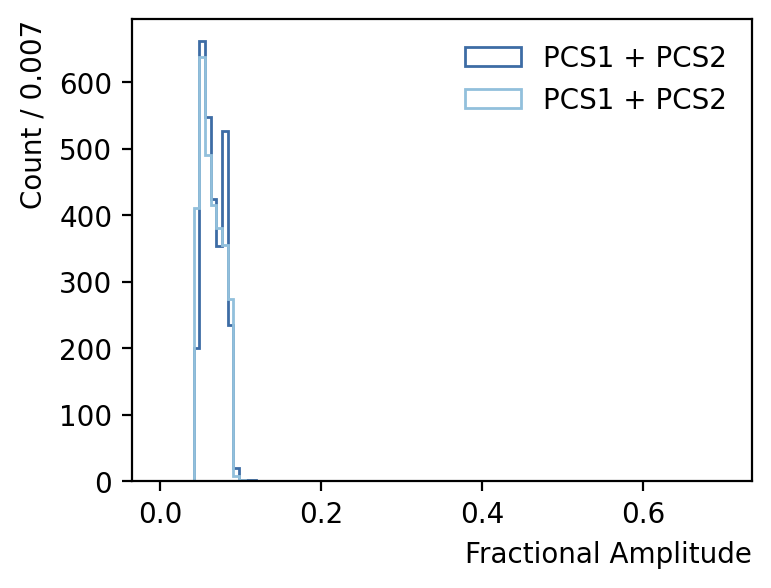

In [90]:
plt.figure(figsize=(4,3), dpi=200)
bins = np.linspace(0, 0.7, 101)

plt.hist(((df_rqs['PAS1OFamps'])/psum)[K_peak_cut], bins, histtype='step', color = c[0], lw = 1, label = 'PCS1 + PCS2')
plt.hist(((df_rqs['PAS2OFamps'])/psum)[K_peak_cut], bins, histtype='step', color = c[1], lw = 1, label = 'PCS1 + PCS2')

plt.xlabel(r"Fractional Amplitude")
plt.ylabel("Count / 0.007")
plt.legend()

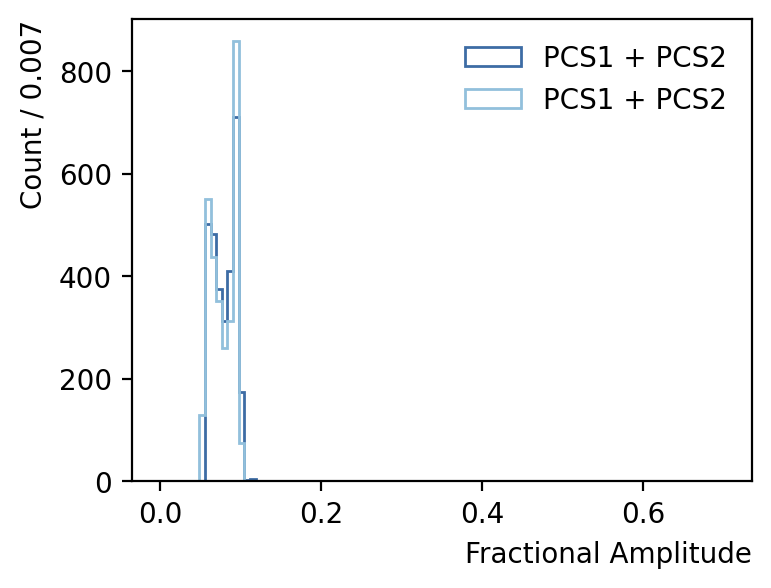

In [92]:
plt.figure(figsize=(4,3), dpi=200)
bins = np.linspace(0, 0.7, 101)

plt.hist(((df_rqs['PBS1OFamps'])/psum)[K_peak_cut], bins, histtype='step', color = c[0], lw = 1, label = 'PCS1 + PCS2')
plt.hist(((df_rqs['PBS2OFamps'])/psum)[K_peak_cut], bins, histtype='step', color = c[1], lw = 1, label = 'PCS1 + PCS2')

plt.xlabel(r"Fractional Amplitude")
plt.ylabel("Count / 0.007")
plt.legend()

In [21]:
B1cut = df_rqs['PBS1OFamps'] == maxOF1
B2cut = df_rqs['PBS2OFamps'] == maxOF2
Bcut = B1cut & B2cut

Text(0, 1, 'Count')

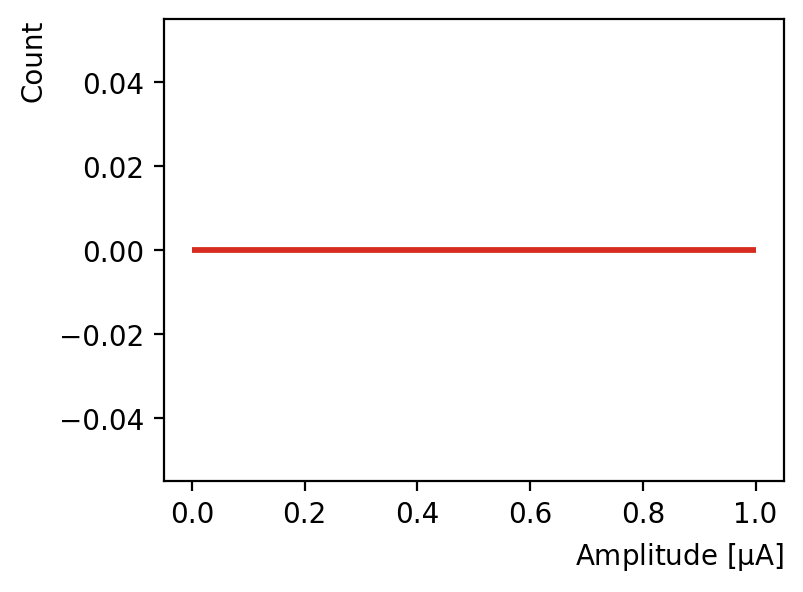

In [22]:
plt.figure(figsize=(4,3), dpi=200)
bins = 50
plt.hist((Fsum/psum)[K_peak_cut & Bcut], bins, histtype='step', color = c[0], lw = 2)
plt.hist((Wedgesum/psum)[K_peak_cut & Bcut], bins, histtype='step', color = c[1], lw = 2)
plt.hist((Bsum/psum)[K_peak_cut & Bcut], bins, histtype='step', color = c[2], lw = 2)
plt.hist((Asum/psum)[K_peak_cut & Bcut], bins, histtype='step', color = c[3], lw = 2)

plt.xlabel(r"Amplitude [$\mathrm{\mu A}$]")
plt.ylabel("Count")

In [23]:
A1cut = df_rqs['PAS1OFamps'] == maxOF1
A2cut = df_rqs['PAS2OFamps'] == maxOF2
Acut = A1cut & A2cut

Text(0, 1, 'Count')

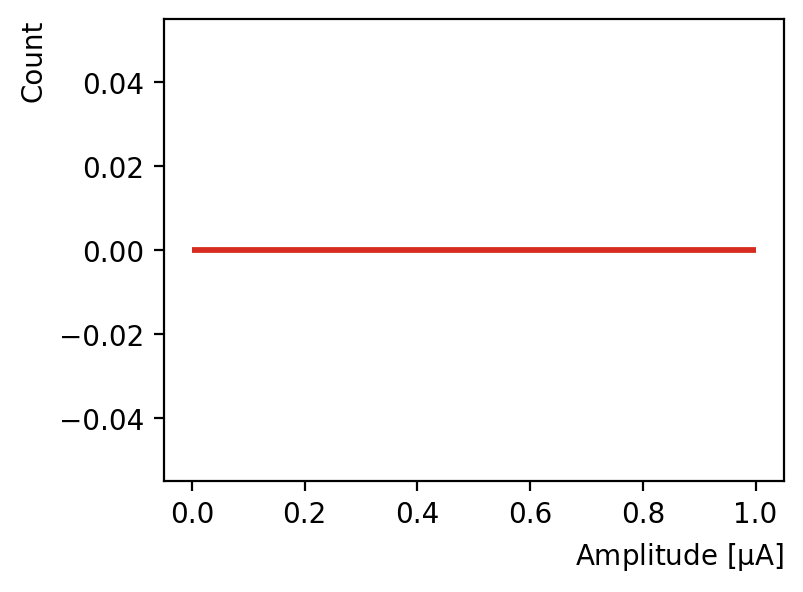

In [24]:
plt.figure(figsize=(4,3), dpi=200)
bins = 50
plt.hist((Fsum/psum)[K_peak_cut & Acut], bins, histtype='step', color = c[0], lw = 2)
plt.hist((Wedgesum/psum)[K_peak_cut & Acut], bins, histtype='step', color = c[1], lw = 2)
plt.hist((Bsum/psum)[K_peak_cut & Acut], bins, histtype='step', color = c[2], lw = 2)
plt.hist((Asum/psum)[K_peak_cut & Acut], bins, histtype='step', color = c[3], lw = 2)

plt.xlabel(r"Amplitude [$\mathrm{\mu A}$]")
plt.ylabel("Count")

Text(0, 1, 'Y [mm]')

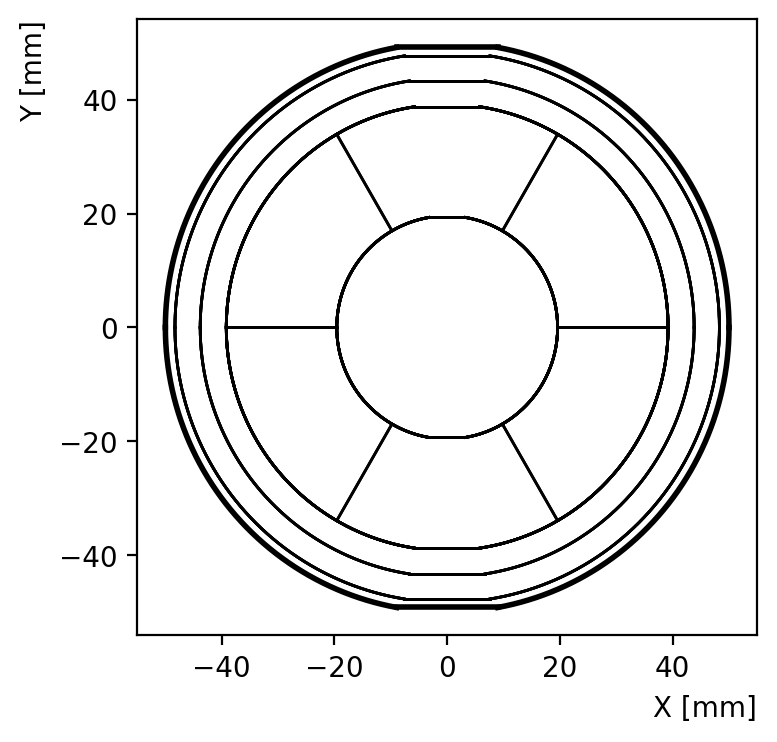

In [25]:
filepath = '/scratch/group/mitchcomp/CDMS/data/nolan/DC3_Production/V2.1.0/DMCER/HV100mm/hits/single/HV100mm_DC3Prod-V2.1.0_BulkER_500eV_10kEvents_Sep9/output/'
filename = 'DMCER_zip_HV100mm_51240909_000000.root'

DMCfile = filepath + filename

plt.figure(figsize=(4, 4), dpi=200)
detectorLayout.drawDetOutline(DMCfile, color='black', lw = 2, ls = '-')
detectorLayout.drawChanOutline(DMCfile, color='black', side=1, chantype=1, labels=0, lw = 1, ls = '-')
detectorLayout.drawChanOutline(DMCfile, color='black', side=2, chantype=1, labels=0, lw = 1, ls = '-')
plt.xlabel('X [mm]')
plt.ylabel('Y [mm]')